In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 31.7 MB/s eta 0:00:00


In [ ]:
import rasterio
import numpy as np
import pandas as pd
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def load_xy_with_dem(x_path, y_path, dem_path):
    # Load Sentinel-based enhanced features
    with rasterio.open(x_path) as src:
        X = src.read()   # shape: (bands, H, W)
        profile = src.profile

    # Load labels
    with rasterio.open(y_path) as src:
        y = src.read(1)  # shape: (H, W)

    # Load DEM-based features (assume 3 bands: slope, elevation, hillshade)
    with rasterio.open(dem_path) as src:
        dem_features = src.read()  # shape: (3, H, W)

    # Stack Sentinel + DEM
    X_combined = np.vstack([X, dem_features])  # (bands + 3, H, W)

    return X_combined, y, profile

To test:

In [ ]:
x_path = "/content/drive/MyDrive/GEE_Exports/neelkanth_x_train_enhanced.tif"
y_path = "/content/drive/MyDrive/GEE_Exports/neelkanth_y_train.tif"
dem_path = "/content/drive/MyDrive/GEE_Exports/DEM/neelkanth.tif"

In [ ]:
X, y, profile = load_xy_with_dem(x_path, y_path, dem_path)
print("X shape (bands+DEM, H, W):", X.shape, "y shape:", y.shape)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 243 and the array at index 1 has size 399

In [ ]:
def flatten_xy(X, y):
    bands, H, W = X.shape
    X_flat = X.reshape(bands, -1).T   # (H*W, bands)
    y_flat = y.flatten()              # (H*W,)

    # Remove NaNs and nodata pixels
    mask = ~np.isnan(X_flat).any(axis=1)
    X_flat = X_flat[mask]
    y_flat = y_flat[mask]

    return X_flat, y_flat

In [ ]:
X_all, y_all = [], []

In [ ]:
aois = ["barlacha", "khanchengyao", "langpo", "samundraTapu",
        "vasuki", "fanchan", "gepang", "karzok"]

for aoi in aois:
    x_path = f"/content/drive/MyDrive/GEE_Exports/{aoi}_x_train_enhanced.tif"
    y_path = f"/content/drive/MyDrive/GEE_Exports/{aoi}_y_train.tif"

    if not os.path.exists(x_path) or not os.path.exists(y_path):
        print(f"⚠️ Skipping {aoi}: missing files")
        continue

    X, y, _ = load_xy(x_path, y_path)
    X_flat, y_flat = flatten_xy(X, y)

    X_all.append(X_flat)
    y_all.append(y_flat)

In [ ]:
X_all = np.vstack(X_all)
y_all = np.hstack(y_all)

In [ ]:
print("Final dataset:", X_all.shape, y_all.shape)

Final dataset: (2056867, 11) (2056867,)


In [ ]:
feature_names = [f"band_{i+1}" for i in range(X_all.shape[1])]
df = pd.DataFrame(X_all, columns=feature_names)
df["label"] = y_all

In [ ]:
csv_path = "/content/drive/MyDrive/GEE_Exports/glacial_lake_dataset.csv"
df.to_csv(csv_path, index=False)
print("Flattened dataset saved as CSV:", csv_path)

Flattened dataset saved as CSV: /content/drive/MyDrive/GEE_Exports/glacial_lake_dataset.csv


In [ ]:
# Load the dataset
csv_path = "/content/drive/MyDrive/GEE_Exports/glacial_lake_dataset.csv"
df = pd.read_csv(csv_path)

# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head())

# Get information about the dataset
print("\nDataset Info:")
df.info()

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# You can add more preprocessing steps here if needed,
# e.g., handling missing values, feature scaling, etc.

First 5 rows of the dataset:


,band_1,band_2,band_3,band_4,band_5,band_6,band_7,band_8,band_9,band_10,band_11,label
0,0.36150,0.37225,0.31695,0.29870,0.08385,0.07200,0.109621,0.632316,1.570791,0.0,122.564680,0.0
1,0.39760,0.42795,0.37685,0.33700,0.06850,0.05905,0.118896,0.724039,1.570791,0.0,100.333435,0.0
2,0.42280,0.42750,0.38225,0.36220,0.14865,0.13720,0.082690,0.483988,1.570789,0.0,120.702020,0.0
3,0.39645,0.41710,0.37845,0.33760,0.11250,0.10895,0.105340,0.575150,1.570791,0.0,113.053610,0.0
4,0.37290,0.39820,0.35910,0.31595,0.11250,0.10895,0.115172,0.559427,1.570792,0.0,96.766400,0.0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2056867 entries, 0 to 2056866
Data columns (total 12 columns):
 #   Column   Dtype  
---  ------   -----  
 0   band_1   float64
 1   band_2   float64
 2   band_3   float64
 3   band_4   float64
 4   band_5   float64
 5   band_6   float64
 6   band_7   float64
 7   band_8   float64
 8   band_9   float64
 9   band_10  float64
 10  band_11  float64
 11  label    float64
dtypes: float64(12)
memory usage: 188.3 MB

Missing values per column:
band_1     0
band_2     0
band_3     0
band_4     0
band_5     0
band_6     0
band_7     0
band_8     0
band_9     0
band_10    0
band_11    0
label      0
dtype: int64


In [ ]:
print("Unique values and their distribution in the 'label' column:")
display(df['label'].value_counts())

Unique values and their distribution in the 'label' column:


,count
label,
1.0,2042596
0.0,14271


# Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.3, stratify=y_all, random_state=42
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=23,
    max_features="sqrt",
    min_samples_leaf=7,
    class_weight="balanced",
    bootstrap=True,
    criterion="gini",
    random_state=42,
    n_jobs=-1
)

Executed in 16.97 mins

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=23,
                       min_samples_leaf=7, n_estimators=250, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred = rf.predict(X_val)
print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.13      0.43      0.20      4281
         1.0       1.00      0.98      0.99    612780

    accuracy                           0.98    617061
   macro avg       0.56      0.70      0.59    617061
weighted avg       0.99      0.98      0.98    617061

[[  1823   2458]
 [ 12540 600240]]


In [ ]:
def predict_raster(rf, x_path, out_path):
    with rasterio.open(x_path) as src:
        X = src.read()
        profile = src.profile
        bands, H, W = X.shape

    # Flatten
    X_flat = X.reshape(bands, -1).T
    mask = ~np.isnan(X_flat).any(axis=1)

    y_pred = np.zeros(X_flat.shape[0], dtype=np.uint8)
    y_pred[mask] = rf.predict(X_flat[mask])

    # Reshape back
    y_pred = y_pred.reshape(H, W)

    # Save as GeoTIFF
    profile.update(count=1, dtype="uint8")
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(y_pred, 1)

    print("Saved prediction raster:", out_path)

Example Usage:

In [ ]:
predict_raster(
    rf,
    "/content/drive/MyDrive/GEE_Exports/vasuki_x_train_enhanced.tif",
    "/content/drive/MyDrive/GEE_Exports/vasuki_predicted.tif"
)

Saved prediction raster: /content/drive/MyDrive/GEE_Exports/vasuki_predicted.tif


## Visualization

In [ ]:
from sklearn.tree import export_graphviz, plot_tree
import matplotlib.pyplot as plt
import graphviz

In [ ]:
feature_names = [
    "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2",  # Sentinel-2 spectral bands
    "NDWI", "NDSI",                                   # Water/Snow indices
    "Slope", "Hillshade", "Elevation"                 # Topographic features
]

In [ ]:
estimator = rf.estimators_[0]

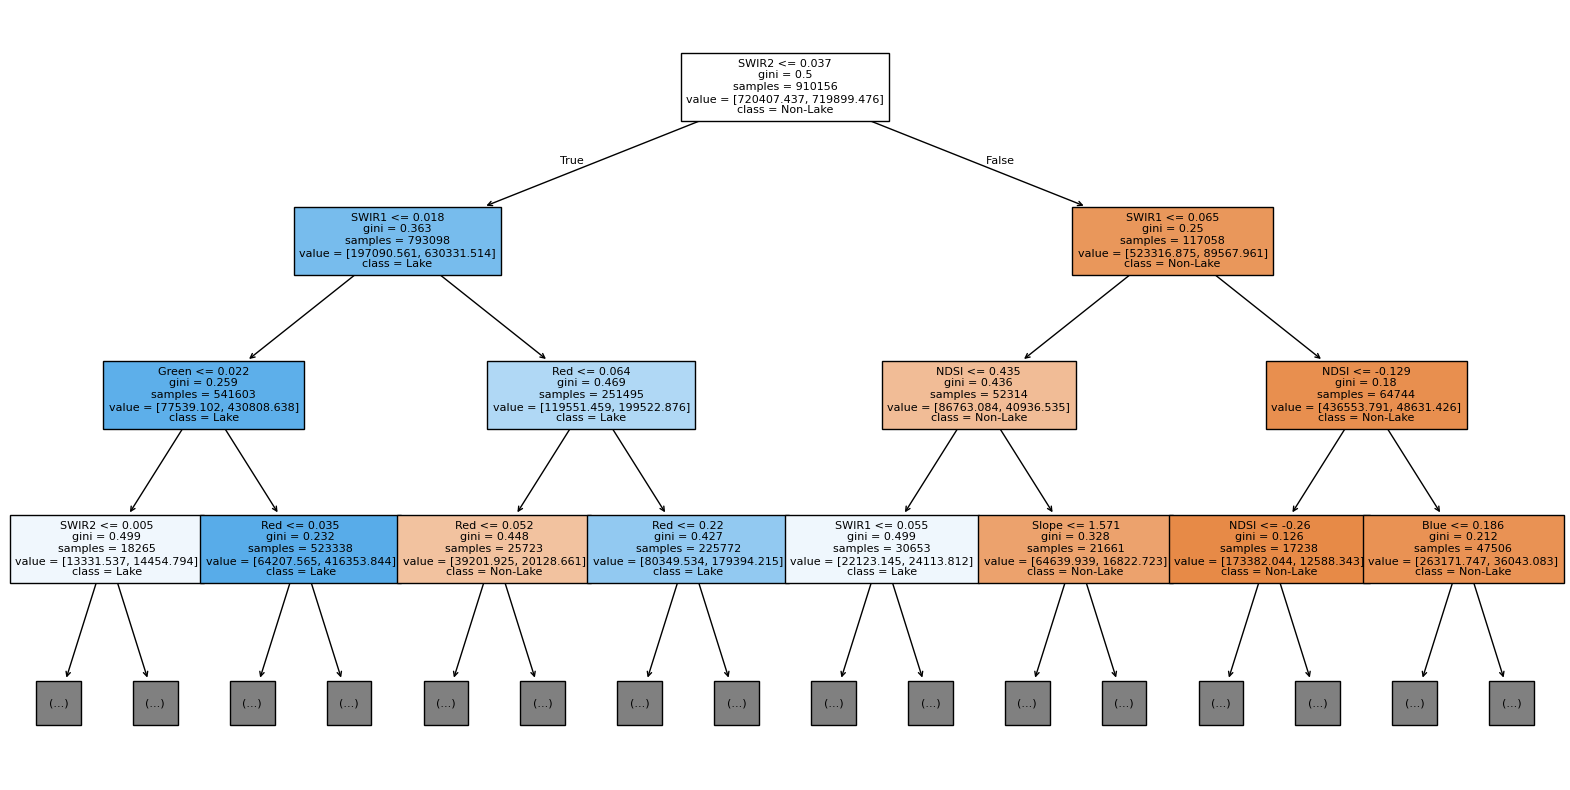

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    estimator,
    feature_names=feature_names,
    class_names=["Non-Lake", "Lake"],
    filled=True,
    max_depth=3,   # only show first few levels for readability
    fontsize=8
)
plt.show()

In [ ]:
dot_data = export_graphviz(
    estimator,
    out_file=None,
    feature_names=feature_names,
    class_names=["Non-Lake", "Lake"],
    filled=True,
    rounded=True,
    special_characters=True,
    max_depth=3   # limit depth for clarity
)

In [ ]:
graph = graphviz.Source(dot_data)
graph.render("/content/drive/MyDrive/GEE_Exports/random_forest_tree", format="png", cleanup=True)
print("Tree visualization saved to Drive.")

Tree visualization saved to Drive.


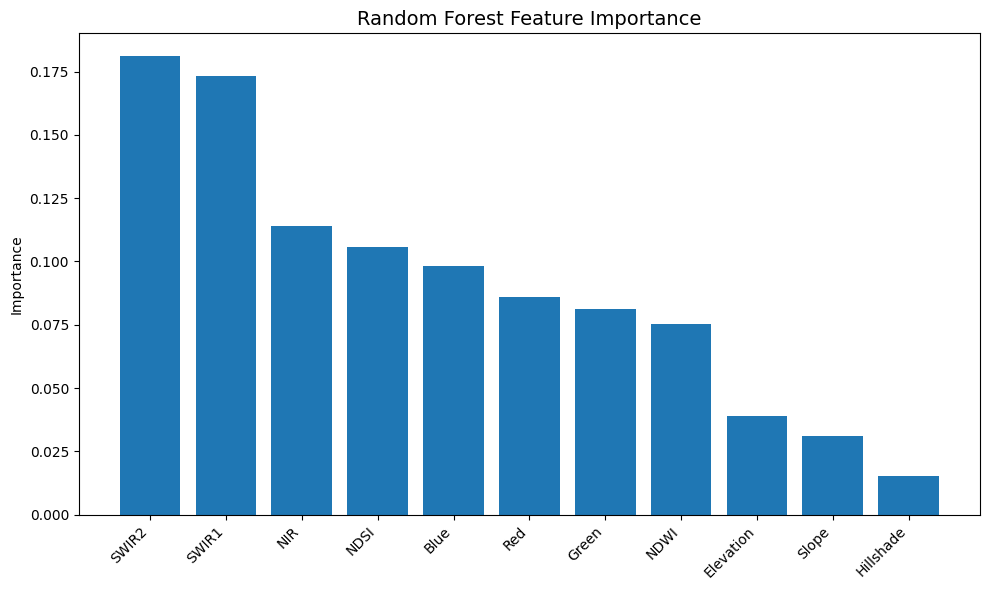

SWIR2: 0.1810
SWIR1: 0.1731
NIR: 0.1141
NDSI: 0.1058
Blue: 0.0983
Red: 0.0861
Green: 0.0810
NDWI: 0.0752
Elevation: 0.0390
Slope: 0.0310
Hillshade: 0.0152


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Human-readable feature names (update if your X bands differ)
feature_names = [
    "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2",   # Sentinel-2 bands
    "NDWI", "NDSI",                                   # Indices
    "Slope", "Hillshade", "Elevation"                 # Topographic features
]

# Get feature importances from the trained Random Forest
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # sort descending

# Plot
plt.figure(figsize=(10, 6))
plt.title("Random Forest Feature Importance", fontsize=14)
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha="right")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# Also print ranked importance
for idx in indices:
    print(f"{feature_names[idx]}: {importances[idx]:.4f}")